# Name: Katie
Add anything else for indentification/or however you want to label this notebook up here before submitting. 

# Submission
You do not need to write up a separate report since there will be space for you to write down thoughts/answer questions throughout this notebook. Instead, when you are finished, go to File --> Save and Export Notebook As --> LaTeX (or as pdf, but this option hasn't been working). This will convert the notebook to a .tex file which can be uploaded into Overleaf and compiled into an already formatted pdf. 

# Introduction
This homework goes over the concepts of calculating $\chi^{2}$ and reduced $\chi^{2}$ to see the goodness of fit of a model to provided data. We then implement an offshoot of this through Markov Chain Monte Carlo (MCMC) Simulations, which use a maximum log-likelihood to judge goodness of fit. It is important to note that maximizing log-likelihood is the same as minimizing chi-squared.

Please watch the following videos, then start filling in the below notebook cells to complete the problems.

Required videos to watch:
1. An introduction to $\chi^{2}$ and reduced $\chi^{2}$: https://www.youtube.com/watch?v=KNLhep3UZ68
2. An introduction to the background of MCMC Simulations: https://www.youtube.com/watch?v=nndtTssgtZE

Optional supplemental materials to read for $\chi^{2}$ and MCMC:
1. https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf - Read sections 2.3-2.4 and 3
2. https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html - Implementation of MCMC

Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
Another important value is the number of degrees of freedom in the model, $\nu$, defined as 
$$\nu = n - p$$
where $n$ is the number of datapoints (measurements) and $p$ are the number of fitted parameters. 

With this, we can determine how well the model has fit the data by using the reduced $\chi^{2}_{\nu}$ which is defined as the chi-square per degree of freedom:

$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error

Taken from: https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf (Section 2.3)

In [2]:
#Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Simple power law [0.5 pts]

To get started, run the cell below. It's some fake noisy data that forms a power law to help ensure that your code is working. Feel free to change the parameters. The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k) by making a brute force $\chi^{2}$ algorithm. 

In [3]:
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5        
k = -1.7 
x = np.linspace(1, 100, 100) #range of x values 
y_true = A*x**k #eqn without noise

noise = np.random.normal(0, 0.20 * y_true) #noise 

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors - they are Gaussian!

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [6]:
# Define functions
def chi2(yobs, ymod, err):
    x = (yobs - ymod) ** 2 / err ** 2
    return np.sum(x)

def chi2nu(chi2, nu):
    return chi2 / nu

### Two Parameter Fit [2 pts]
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Print out some of these values for a few of the iterations to see how they change. What do you notice? Hint: Define a grid of values for $\chi^{2}$ to search through. 


Note: This is a brute force method that explores the whole defined parameter space. It does not try to get the lowest-chi squre value.

In [35]:
# Two param fit
ypower = lambda x: A * x ** k    #define the model

A_arr = range(1, 6)
k_arr = np.linspace(-2, 2, 5)
chi2power = np.zeros((5, 5))
chi2nupower = np.zeros((5, 5))
nu = len(x) - 1

for i in range(5):
    A = A_arr[i]
    for j in range(5):
        k = k_arr[j]
        ymod = ypower(x)
        chi2power[i, j] = chi2(y, ymod, y_err)
        chi2nupower[i, j] = chi2nu(chi2power[i, j], nu)

print(chi2power)

[[2.14743822e+03 1.44587982e+04 1.45643239e+08 1.01763422e+12
  7.83076090e+15]
 [1.84369791e+03 7.96508531e+04 5.84428120e+08 4.07067371e+12
  3.13230544e+16]
 [1.56766317e+03 1.98055049e+05 1.31635712e+09 9.15911849e+12
  7.04768806e+16]
 [1.31933401e+03 3.69671385e+05 2.34143024e+09 1.62829686e+13
  1.25292239e+17]
 [1.09871043e+03 5.94499862e+05 3.65964749e+09 2.54422239e+13
  1.95769131e+17]]


Comments:  The A values are increasing from 1 to 5 moving top to bottom and the k values are increasing from -2 to 2 from left to right.

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [37]:
# Get the best values - The printed output is fine
index = np.argmin(chi2nupower)
Aindex = (index) // 5
kindex = index % 5
print(f'The lowest \u03c7\u00b2\u1D65 is {chi2nupower[Aindex, kindex]:.2g}, with a \u03c7\u00b2 of {chi2power[Aindex, kindex]:.2g}, a A value of {A_arr[Aindex]:.2g} and a k value of {k_arr[kindex]:.2g}.')

The lowest χ²ᵥ is 11, with a χ² of 1.1e+03, a A value of 5 and a k value of -2.


Plot the data, model with the best-fit parameters, and residuals in log-log space (You should see a line). Comment on the fit.

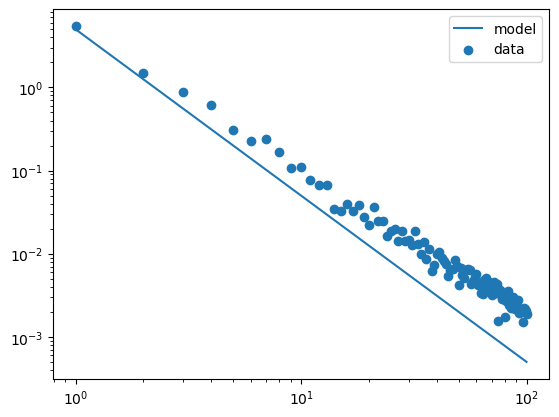

In [39]:
# Plot in loglog - You should see a line
A = A_arr[Aindex]
k = k_arr[kindex]
ybest = ypower(x)

plt.loglog(x, ybest, label = 'model')
plt.scatter(x, y, label = 'data')
plt.legend()

Comments: The data falls a bit above the line which has a slightly steeper slope, but the line is close to the data.

We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. Include a point indicating your best fit parameters. Comment on the parameter space in relation to thest best-fit values.

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, which is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

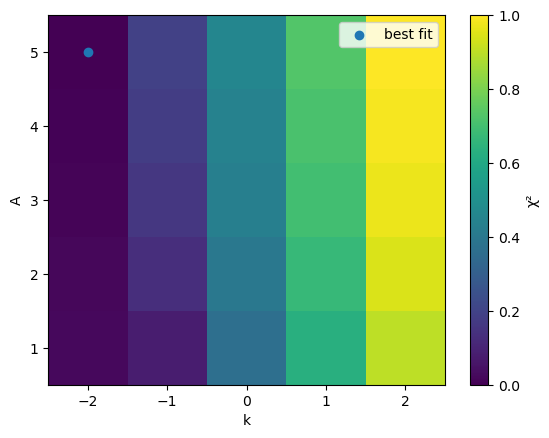

In [44]:
# Contour plot
plt.pcolormesh(k_arr, A_arr, chi2power, norm = LogNorm(np.min(chi2power), np.max(chi2power)))
plt.scatter(k, A, label = 'best fit')
plt.xlabel('k')
plt.ylabel('A')
plt.colorbar(label = '\u03c7\u00b2')
plt.legend()

Comments:

## Real Data [2 pts]
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds mass ($M_{\odot}$), log stellar age (log years), log accretion rate (log $M_{\odot}/yr$), and log accretion rate errors. Note: The data is already in log scale, so how will that change your model function?

In [60]:
# Load in the data
Mstar, logAge, logMacc, logMaccErr = np.loadtxt('HW07_Stellar_Data.txt', skiprows = 1, unpack = True)

In [62]:
# New model function here
ylog = lambda x: np.log(A) + k * np.log(x)

Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters with their $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [ ]:
# Brute force method
A_arr = np.linspace(1E-5, 1, 10)
k_arr = np.linspace(-1.5, -1, 10)
chi2log = np.zeros((5, 5))
chi2nulog = np.zeros((5, 5))
nu = len(Mstar) - 2

#using same A and k values from last problem
for i in range(5):
    A = A_arr[i]
    for j in range(5):
        k = k_arr[j]
        ymod1 = ylog(Mstar)
        ymod2 = ylog(logAge)
        chi2log[i, j] = chi2(logMacc, ymod1, logMaccErr) + chi2(logMacc, ymod2, logMaccErr)
        chi2nulog[i, j] = chi2nu(chi2log[i, j], nu)

print(f'The \u03c7\u00b2\u1D65 values are {chi2nulog}')
print(f'The \u03c7\u00b2 values are {chi2log}')
print(np.min(chi2nulog))

The χ²ᵥ values are [[5125.05974125 4997.71099645 4872.80975101 4750.35600494 4630.34975823]
 [5307.48251274 5349.65913999 5394.2832666  5441.35489258 5490.87401793]
 [6782.11848543 6836.90794749 6894.14490892 6953.82936971 7015.96132987]
 [7738.55829389 7800.72599738 7865.34120024 7932.40390247 8001.91410406]
 [8459.16569377 8526.56840006 8596.41860571 8668.71631073 8743.46151512]]
The χ² values are [[1189013.85997029 1159468.95117546 1130491.86223373 1102082.59314509
  1074241.14390955]
 [1231335.94295628 1241120.92047727 1251473.71785136 1262394.33507854
  1273882.77215881]
 [1573451.48861997 1586162.64381802 1599441.61886916 1613288.41377341
  1627703.02853075]
 [1795345.52418175 1809768.43139207 1824759.1584555  1840317.70537202
  1856444.07214163]
 [1962526.44095564 1978163.86881385 1994369.11652515 2011142.18408955
  2028483.07150704]]
4630.349758230808


Comments: Like before, the A values are increasing from 1 to 5 moving top to bottom and the k values are increasing from -2 to 2 from left to right. It appears that the better fit falls in lower values for both k and A

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding parameters and $\chi^{2}$. These are your best fit parameters.

In [ ]:
# Best-fit params

As before, plot the data with errors, model with the best-fit parameters, and residuals in log-log space. Make sure to include units on the plot. Comment on the fit. Look back at $\chi^{2}_{\nu}$ value you got, what does this value mean for your model? How could one improve $\chi^{2}_{\nu}$? 

In [ ]:
# Plot it up

Comments

Answers:

Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Add the point indicating your best-fit parameters. Comment on the parameter space in relation to these best-fit values. 

In [ ]:
# Contour plot

Comments:

# Fitting Stellar Accretion [5.5 pts]

In this part we are going to be using the the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/

We will work through the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC.

In [ ]:
import emcee

First, load Stellar_Data.txt into the notebook and make a scatter plot of logAge vs logMacc. Note: the data is already logarithmic. [0.5 pts]

In [ ]:
# Load data and plot

Create the linear model definition, the log likelihood definition, the lnprior definition, and the posterior probability definition. [1 pnt]

In [ ]:
# Linear Model Def

# Log Likelihood Def

# lnprior Def

# Posterior Prob Def

Use the definitions to run the emcee. Your number of walkers should be some power of 2, and your number of iterations should be some value over 100. [1 pts]

In [ ]:
# Parameters

# Run MCMC

Make a plot of the parameters' values over each step (typically referred to as a convergence or trace study). Comment on the value of the parameters as the MCMC runs. Hint: This information is encoded in the get_chain() function. [1 pnt]

In [ ]:
# Plot parameter values versus steps (iterations)

After running emcee, plot the original data with the best fit line calculated from the emcee. Comment on the plot. [1 pnt]

In [ ]:
# Plot data and best-fit line

Comments:

Finally, use the original data, its errors, and the emcee model data to calculate $\chi^{2}$ and $\chi^{2}_{v}$. Comment on the results. [1 pnt]

In [ ]:
# Calculate chi-squared

# Calculate reduced chi-squared

Comments: